# 🤖 Sprint 2 — Baseline Model Comparison

**Objective:** Train 6 baseline classifiers (no tuning), compare on Accuracy / Precision / Recall / F1 / AUC-ROC, and identify the top candidates for further tuning.

---

In [8]:
%pip install mlflow
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load_data import load_raw_data
from src.data.clean_data import clean_data
from src.features.encode import frequency_encode, one_hot_encode
from src.models.train import train_models
from src.models.evaluate import (
    plot_confusion_matrix, plot_roc_curves, classification_report_df
)
from src.utils.config import (
    TARGET, CATEGORICAL_LOW_CARD, CATEGORICAL_HIGH_CARD,
    FIGURES_DIR, REPORTS_DIR
)

sns.set_theme(style='whitegrid')
%matplotlib inline
%pip install mlflow


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 6.33.6 which is incompatible.



  Using cached waitress-3.0.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/11.2 MB ? eta -:--:--
   ------ --------------------------------- 1.8/11.2 MB 10.0 MB/s eta 0:00:01
   -------------- ------------------------- 4.2/11.2 MB 10.9 MB/s eta 0:00:01
   ------------------------ --------------- 6.8/11.2 MB 11.3 MB/s eta 0:00:01
   ------------------------------- -------- 8.9/11.2 MB 11.1 MB/s eta 0:00:01
   ---------------------------------------  11.0/11.2 MB 11.3 MB/s eta 0:00:01
   ---------------------------------------- 11.2/11.2 MB 10.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/3.6 MB ? eta -:--:--
   ----------------------------- ---------- 2.6/3.6 MB 12.5 MB/s eta 0:00:01
   ---------------------------------------- 3.6/3.6 MB 11.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 9.8 MB/s eta 0:00:00
   -----------------------

## 1. Load & Prepare Data

In [9]:
# Load and clean
df = clean_data(load_raw_data())

# Encode
df, _ = frequency_encode(df, CATEGORICAL_HIGH_CARD)
df = one_hot_encode(df, CATEGORICAL_LOW_CARD)

# Separate target
y = df[TARGET]
X = df.drop(columns=[TARGET])

# Drop any remaining non-numeric columns
X = X.select_dtypes(include=[np.number])

print(f'X shape: {X.shape}')
print(f'y distribution:\n{y.value_counts()}')

2026-08-25 01:03:43 │ INFO     │ src.data.load_data │ Loading raw data from C:\Users\pares\OneDrive\Desktop\hotle_cnacelation\hotel_bookings.csv
2026-08-25 01:03:44 │ INFO     │ src.data.load_data │ Shape: (119390, 32)
2026-08-25 01:03:44 │ INFO     │ src.data.load_data │ Columns: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']
2026-08-25 01:03:44 │ WARNING  │ src.data.load_data │ Columns with nulls:
children         4
countr

c:\Users\pares\OneDrive\Desktop\hotle_cnacelation\src\data\clean_data.py:68: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["children"].fillna(0, inplace=True)
c:\Users\pares\OneDrive\Desktop\hotle_cnacelation\src\data\clean_data.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

2026-08-25 01:03:46 │ INFO     │ src.data.clean_data │ Removed 181 invalid rows (negative ADR / zero guests)
2026-08-25 01:03:46 │ INFO     │ src.data.clean_data │ Converted arrival_date_month to numeric (1–12)
2026-08-25 01:03:47 │ INFO     │ src.data.clean_data │ Dropped 32246 duplicate rows
2026-08-25 01:03:48 │ INFO     │ src.data.clean_data │ Cleaned data saved to C:\Users\pares\OneDrive\Desktop\hotle_cnacelation\data\interim\hotel_bookings_cleaned.csv  (output shape: (86963, 29))
2026-08-25 01:03:48 │ INFO     │ src.features.encode │ Frequency-encoded 'country'  (178 categories)
2026-08-25 01:03:48 │ INFO     │ src.features.encode │ One-hot encoded 8 columns → 60 total columns
X shape: (86963, 59)
y distribution:
is_canceled
0    63213
1    23750
Name: count, dtype: int64


## 2. Train All Baseline Models

In [10]:
results, X_train, X_test, y_train, y_test = train_models(
    X, y, use_mlflow=False
)

print('\n✅ All models trained!')
for name, (model, metrics) in results.items():
    print(f'  {name}: {metrics}')

2026-08-25 01:03:51 │ WARNING  │ src.models.train │ lightgbm not installed — skipping LGBMClassifier
2026-08-25 01:03:52 │ INFO     │ src.models.train │ Train/test split: train=69570, test=17393
2026-08-25 01:03:52 │ INFO     │ src.models.train │ Training LogisticRegression …


c:\Users\pares\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


2026-08-25 01:04:06 │ INFO     │ src.models.train │ LogisticRegression → {'accuracy': 0.7852, 'precision': 0.6711, 'recall': 0.4187, 'f1': 0.5157, 'roc_auc': 0.7954}
2026-08-25 01:04:06 │ INFO     │ src.models.train │ Training DecisionTree …


c:\Users\pares\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


2026-08-25 01:04:08 │ INFO     │ src.models.train │ DecisionTree → {'accuracy': 0.7989, 'precision': 0.6319, 'recall': 0.632, 'f1': 0.6319, 'roc_auc': 0.7476}
2026-08-25 01:04:08 │ INFO     │ src.models.train │ Training RandomForest …
2026-08-25 01:04:14 │ INFO     │ src.models.train │ RandomForest → {'accuracy': 0.8466, 'precision': 0.7646, 'recall': 0.6333, 'f1': 0.6928, 'roc_auc': 0.9076}
2026-08-25 01:04:14 │ INFO     │ src.models.train │ Training GradientBoosting …
2026-08-25 01:05:05 │ INFO     │ src.models.train │ GradientBoosting → {'accuracy': 0.8371, 'precision': 0.7541, 'recall': 0.5985, 'f1': 0.6674, 'roc_auc': 0.8964}
2026-08-25 01:05:05 │ INFO     │ src.models.train │ Training XGBoost …


c:\Users\pares\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:05:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


2026-08-25 01:05:08 │ INFO     │ src.models.train │ XGBoost → {'accuracy': 0.8514, 'precision': 0.7503, 'recall': 0.6832, 'f1': 0.7152, 'roc_auc': 0.9169}

✅ All models trained!
  LogisticRegression: {'accuracy': 0.7852, 'precision': 0.6711, 'recall': 0.4187, 'f1': 0.5157, 'roc_auc': 0.7954}
  DecisionTree: {'accuracy': 0.7989, 'precision': 0.6319, 'recall': 0.632, 'f1': 0.6319, 'roc_auc': 0.7476}
  RandomForest: {'accuracy': 0.8466, 'precision': 0.7646, 'recall': 0.6333, 'f1': 0.6928, 'roc_auc': 0.9076}
  GradientBoosting: {'accuracy': 0.8371, 'precision': 0.7541, 'recall': 0.5985, 'f1': 0.6674, 'roc_auc': 0.8964}
  XGBoost: {'accuracy': 0.8514, 'precision': 0.7503, 'recall': 0.6832, 'f1': 0.7152, 'roc_auc': 0.9169}


## 3. Comparison Table

In [11]:
comparison = pd.DataFrame({
    name: metrics for name, (_, metrics) in results.items()
}).T

comparison = comparison.sort_values('f1', ascending=False)
comparison.style.background_gradient(cmap='Greens', subset=['accuracy', 'f1', 'roc_auc'])

,accuracy,precision,recall,f1,roc_auc
XGBoost,0.851400,0.750300,0.683200,0.715200,0.916900
RandomForest,0.846600,0.764600,0.633300,0.692800,0.907600
GradientBoosting,0.837100,0.754100,0.598500,0.667400,0.896400
DecisionTree,0.798900,0.631900,0.632000,0.631900,0.747600
LogisticRegression,0.785200,0.671100,0.418700,0.515700,0.795400


In [12]:
# Save comparison as markdown
md_table = comparison.to_markdown()
with open(REPORTS_DIR / 'model_comparison.md', 'w') as f:
    f.write('# Baseline Model Comparison\n\n')
    f.write(f'**Dataset shape:** {X.shape}\n\n')
    f.write(md_table)
    f.write('\n\n> Models trained with default hyperparameters. '
            'Top candidates will proceed to Sprint 3 tuning.\n')
print('✅ Comparison saved to reports/model_comparison.md')

✅ Comparison saved to reports/model_comparison.md


## 4. Visualization — Metrics Bar Chart

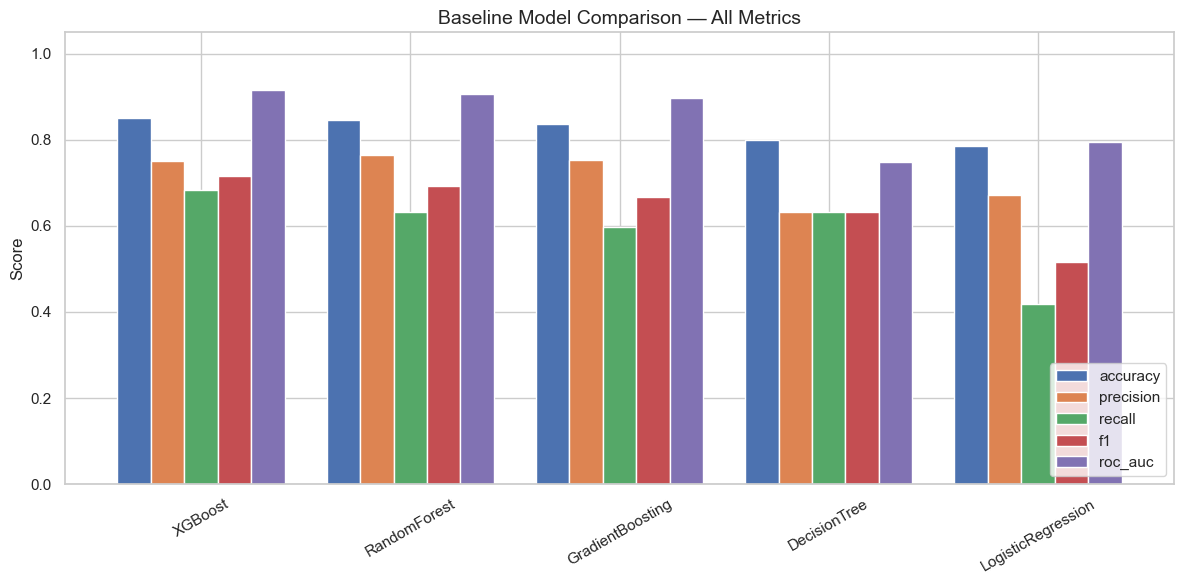

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
comparison[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].plot(
    kind='bar', ax=ax, edgecolor='white', width=0.8
)
ax.set_title('Baseline Model Comparison — All Metrics', fontsize=14)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'baseline_comparison.png', dpi=150)
plt.show()

## 5. Confusion Matrices

In [14]:
for name, (model, _) in results.items():
    plot_confusion_matrix(model, X_test, y_test, model_name=name)
    print(f'  Saved confusion matrix for {name}')

2026-08-25 01:05:54 │ INFO     │ src.models.evaluate │ Confusion matrix saved to C:\Users\pares\OneDrive\Desktop\hotle_cnacelation\reports\figures\confusion_matrix_LogisticRegression.png
  Saved confusion matrix for LogisticRegression
2026-08-25 01:05:55 │ INFO     │ src.models.evaluate │ Confusion matrix saved to C:\Users\pares\OneDrive\Desktop\hotle_cnacelation\reports\figures\confusion_matrix_DecisionTree.png
  Saved confusion matrix for DecisionTree
2026-08-25 01:05:55 │ INFO     │ src.models.evaluate │ Confusion matrix saved to C:\Users\pares\OneDrive\Desktop\hotle_cnacelation\reports\figures\confusion_matrix_RandomForest.png
  Saved confusion matrix for RandomForest
2026-08-25 01:05:56 │ INFO     │ src.models.evaluate │ Confusion matrix saved to C:\Users\pares\OneDrive\Desktop\hotle_cnacelation\reports\figures\confusion_matrix_GradientBoosting.png
  Saved confusion matrix for GradientBoosting
2026-08-25 01:05:56 │ INFO     │ src.models.evaluate │ Confusion matrix saved to C:\User

## 6. ROC Curves

In [15]:
models_only = {name: model for name, (model, _) in results.items()}
plot_roc_curves(models_only, X_test, y_test)
print('✅ ROC curves saved')

2026-08-25 01:06:01 │ INFO     │ src.models.evaluate │ ROC curves saved to C:\Users\pares\OneDrive\Desktop\hotle_cnacelation\reports\figures\roc_curves_comparison.png
✅ ROC curves saved


## 7. Detailed Classification Reports

In [16]:
# Show report for best model
best_name = comparison.index[0]
best_model = results[best_name][0]
print(f'\n📊 Classification Report — {best_name}\n')
report = classification_report_df(best_model, X_test, y_test)
report


📊 Classification Report — XGBoost



,precision,recall,f1-score,support
0,0.884833,0.914577,0.899459,12643.000000
1,0.750289,0.683158,0.715152,4750.000000
accuracy,0.851377,0.851377,0.851377,0.851377
macro avg,0.817561,0.798868,0.807305,17393.000000
weighted avg,0.848089,0.851377,0.849125,17393.000000


## Summary

- Trained 6 models with default hyperparameters
- Best model by F1 score identified above
- Top 2–3 candidates selected for Sprint 3 (Feature Engineering + Hyperparameter Tuning)
- All plots saved to `reports/figures/`